# 04 · Data Preparation — pembersihan, label lonjakan, jaringan rambatan, rekayasa fitur
Fase CRISP-DM 3: **Select → Clean → Construct → Integrate → Format data**.

Output utama:
- `data/processed/panel_pt{1..4}.parquet` — panel harga harian bersih per jenis pasar
- `data/processed/events.parquet` — daftar kejadian lonjakan
- `data/processed/network_edges*.parquet`, `leader_scores*.parquet` — jaringan rambatan antarprovinsi
- `data/processed/features.parquet` (untuk evaluasi walk-forward) & `features_final.parquet` (untuk model produksi)
- `reports/tables/04_data_dictionary.csv` — kamus fitur

> **Prinsip anti-kebocoran (*leakage*)**: setiap fitur pada tanggal `t` hanya boleh memakai informasi yang sudah tersedia pada `t`. Prinsip ini dibuktikan dengan **uji leakage** di bagian 4.6.

In [1]:
# --- Setup: path project, modul radarpangan, gaya grafik -----------------------------------
import sys, json, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from radarpangan.config import load_project
cfg, P = load_project(ROOT)
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": .3, "font.size": 10})
print("Project:", ROOT)

Project: /home/claude/MiningProcess


In [2]:
import time
from radarpangan.pipeline import load_refs, save_panel, feature_columns
from radarpangan.cleaning import build_price_panels, long_to_wide, detect_bad_values, smooth_trailing
from radarpangan.labeling import make_labels, threshold_per_column, events_table
from radarpangan.network import build_network, select_leaders, granger_pairwise, weekly_returns
from radarpangan.reference import province_reference, nearest_neighbors, holiday_table, calendar_features
from radarpangan.weather import rainfall_anomalies
from radarpangan.features import build_features, feature_dictionary, ID_COLS, LABEL_COLS
from radarpangan.viz import plot_network_map, PALETTE
from radarpangan.geo import load_geojson

refs = load_refs(P)
long = pd.read_parquet(P.interim / "pihps_long.parquet")
rain_daily = pd.read_parquet(P.interim / "rainfall_daily.parquet")
geo = load_geojson(P.external / "indonesia_provinces.geojson")
print(f"Data harga: {len(long):,} baris | curah hujan: {len(rain_daily):,} baris")

Data harga: 5,450,980 baris | curah hujan: 443,836 baris


## 4.1 Seleksi data

| Keputusan | Alasan |
|---|---|
| Periode **Jan 2018 – terbaru** | Sebelum 2018 hanya sebagian provinsi |
| **Target = harga konsumen (Pasar Tradisional)** | Paling relevan untuk daya beli & inflasi; cakupan paling lengkap |
| Pasar Modern, Pedagang Besar, Produsen → **fitur** | Sinyal rantai pasok |
| **21 varian × 34 provinsi** (+ nasional untuk fitur) | Seluruh cakupan PIHPS |
| Buang baris wilayah dummy (`"Dum"`) | Tidak berisi data |
| Origin prediksi hanya **hari kerja**, mulai **April 2018** | PIHPS tidak rilis data akhir pekan; 3 bulan pertama = *warm-up* fitur |

## 4.2 Pembersihan data
Langkah per jenis pasar: *long → wide* → buang salah input (blip 1 hari & salah skala) → median bergulir 3 observasi (trailing) → panel **kalender harian** + *forward-fill* maks. 7 hari.

In [3]:
t0 = time.time()
panels, clean_log = build_price_panels(long, cfg)
print(f"Selesai dalam {time.time() - t0:.1f} dtk")
cl = clean_log.groupby("price_type_id")[["n_obs", "n_removed"]].sum()
cl.index = cl.index.map({1: "Pasar Tradisional", 2: "Pasar Modern", 3: "Pedagang Besar", 4: "Produsen"})
cl["persen_dibuang"] = cl["n_removed"] / cl["n_obs"]
display(cl)
for pt, pan in panels.items():
    save_panel(pan, P.processed / f"panel_pt{pt}.parquet")
    print(f"panel_pt{pt}: {pan.shape[0]:,} hari x {pan.shape[1]} seri, terisi {pan.notna().mean().mean():.1%}")

Selesai dalam 7.2 dtk


,n_obs,n_removed,persen_dibuang
price_type_id,,,
Pasar Tradisional,1569873,143,0.0001
Pasar Modern,1286636,49,0.0000
Pedagang Besar,1566791,14,0.0000
Produsen,901570,15,0.0000


panel_pt1: 3,190 hari x 724 seri, terisi 98.5%
panel_pt2: 3,190 hari x 696 seri, terisi 82.2%


panel_pt3: 3,190 hari x 710 seri, terisi 97.7%
panel_pt4: 3,190 hari x 472 seri, terisi 84.5%


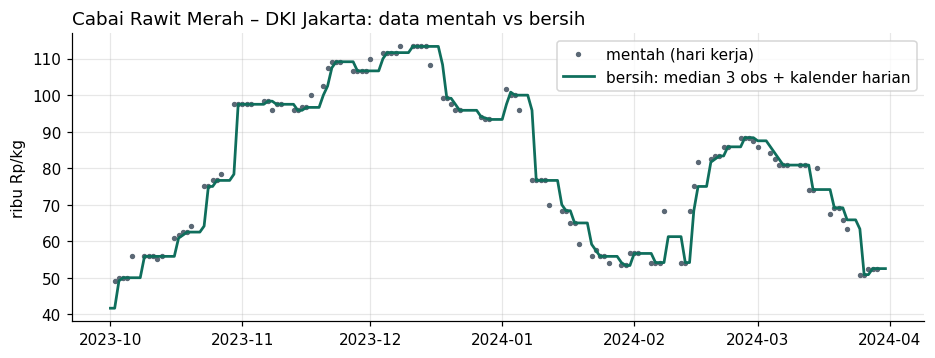

In [4]:
# Sebelum vs sesudah pembersihan: contoh Cabai Rawit Merah - DKI Jakarta
col = ("com_16", 13)
raw = long_to_wide(long, 1)[col].loc["2023-10-01":"2024-03-31"]
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(raw.index, raw / 1000, "o", ms=2.5, color=PALETTE["muted"], label="mentah (hari kerja)")
cl_ = panels[1][col].loc["2023-10-01":"2024-03-31"]
ax.plot(cl_.index, cl_ / 1000, color=PALETTE["accent"], lw=1.8, label="bersih: median 3 obs + kalender harian")
ax.set_ylabel("ribu Rp/kg"); ax.legend(); ax.set_title("Cabai Rawit Merah – DKI Jakarta: data mentah vs bersih", loc="left")
fig.savefig(P.figures / "fig_04_01_pembersihan.png", dpi=160, bbox_inches="tight"); plt.show()

## 4.3 Konstruksi target: kejadian lonjakan & label peringatan dini

- $r_{14}(t) = P_t / P_{t-14} - 1$ (harga konsumen bersih, 14 hari kalender)
- **Status lonjak**: $r_{14}(t) > \theta_k$ ( $\theta$ = 15%; beras 5%; gula/minyak/sapi 7,5% — lihat notebook 03)
- **Onset (kejadian)**: hari pertama status lonjak setelah ≥ 14 hari tidak lonjak (*cooldown*)
- **Label** $y(t) = 1$ jika ada onset di $(t, t+14]$ — "apakah dalam 2 minggu ke depan akan terjadi lonjakan?"
- **eligible(t)**: hanya baris yang **tidak sedang lonjak** dipakai melatih/menguji alarm (alarm berguna *sebelum* lonjakan). Baris yang sedang lonjak ditampilkan di dashboard sebagai status "Sedang lonjak".

In [5]:
Pc = panels[cfg["target"]["price_type"]]
thr = threshold_per_column(Pc.columns, refs["c2cat"], cfg)
labels = make_labels(Pc, thr, cfg)
events = events_table(labels, Pc)
events = events[events["province_id"] != 0].reset_index(drop=True)
events.to_parquet(P.processed / "events.parquet", index=False)
events["kategori"] = events["commodity_id"].map(refs["c2cat"]).map(refs["cat_name"])
print(f"Total kejadian lonjakan: {len(events):,}")
display(events.groupby("kategori").agg(kejadian=("date", "size"), median_kenaikan_saat_onset=("rise_at_onset", "median"),
        median_kenaikan_puncak_30h=("peak_rise_30d", "median")).sort_values("kejadian", ascending=False)
        .style.format({"median_kenaikan_saat_onset": "{:.1%}", "median_kenaikan_puncak_30h": "{:.1%}"}))

Total kejadian lonjakan: 8,457


,kejadian,median_kenaikan_saat_onset,median_kenaikan_puncak_30h
kategori,,,
Cabai Merah,2905,19.1%,38.3%
Cabai Rawit,2464,18.8%,43.6%
Bawang Merah,798,17.3%,33.0%
Beras,689,5.9%,7.9%
Daging Ayam,399,16.8%,22.9%
Minyak Goreng,387,9.3%,14.3%
Bawang Putih,254,17.5%,31.6%
Daging Sapi,245,9.1%,10.8%
Gula Pasir,168,8.6%,12.2%


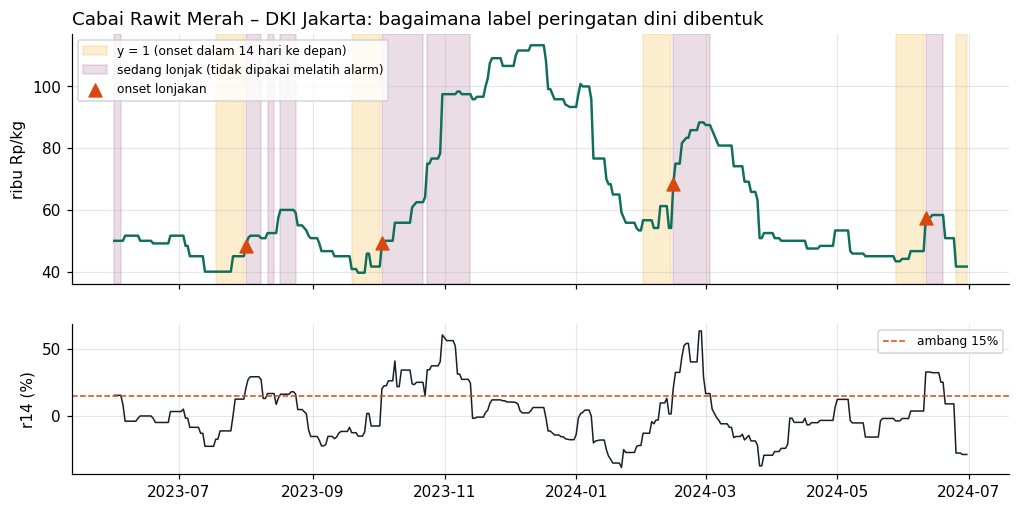

In [6]:
# Ilustrasi label pada satu seri
col = ("com_16", 13); a, b = "2023-06-01", "2024-06-30"
s = Pc[col].loc[a:b]; r = labels["r14"][col].loc[a:b]; yv = labels["y"][col].loc[a:b]
ons = labels["onset"][col].loc[a:b]; sp = labels["spike"][col].loc[a:b]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5.2), sharex=True, gridspec_kw={"height_ratios": [2, 1.2]})
ax1.plot(s.index, s / 1000, color=PALETTE["accent"], lw=1.6)
ax1.fill_between(s.index, 0, 1, where=(yv == 1).to_numpy(), transform=ax1.get_xaxis_transform(), color=PALETTE["watch"], alpha=.25, label="y = 1 (onset dalam 14 hari ke depan)")
ax1.fill_between(s.index, 0, 1, where=(sp == 1).to_numpy(), transform=ax1.get_xaxis_transform(), color=PALETTE["spike"], alpha=.15, label="sedang lonjak (tidak dipakai melatih alarm)")
od = ons[ons == 1].index
ax1.scatter(od, s.loc[od] / 1000, marker="^", s=70, color=PALETTE["high"], zorder=5, label="onset lonjakan")
ax1.set_ylabel("ribu Rp/kg"); ax1.legend(fontsize=8, loc="upper left")
ax1.set_title("Cabai Rawit Merah – DKI Jakarta: bagaimana label peringatan dini dibentuk", loc="left")
ax2.plot(r.index, r * 100, color=PALETTE["ink"], lw=1)
ax2.axhline(thr[col] * 100, color=PALETTE["high"], ls="--", lw=1, label=f"ambang {thr[col]:.0%}")
ax2.set_ylabel("r14 (%)"); ax2.legend(fontsize=8)
fig.savefig(P.figures / "fig_04_02_ilustrasi_label.png", dpi=160, bbox_inches="tight"); plt.show()

## 4.4 Konstruksi jaringan rambatan antarprovinsi (lead-lag)

Untuk setiap varian, setiap pasangan provinsi A → B diuji dengan **Granger causality bersyarat** pada return mingguan:

$$\Delta \ln P_{B,t} = c + \sum_{k=1}^{2}\alpha_k \Delta \ln P_{B,t-k} + \sum_{k=1}^{2}\gamma_k \Delta \ln P_{Nas,t-k} + \sum_{k=1}^{2}\beta_k \Delta \ln P_{A,t-k} + \varepsilon_t$$

Uji F untuk $H_0: \beta_1=\beta_2=0$. Kontrol harga nasional mencegah gelombang nasional (mis. Lebaran) terbaca sebagai rambatan. *p-value* dikoreksi **Benjamini–Hochberg (FDR)**; edge dianggap signifikan jika $q < 0{,}05$ dan $\sum \beta_k > 0$. Sebagai bukti tambahan dihitung **presedensi kejadian**: berapa persen onset di A diikuti onset di B dalam 1–14 hari, dibanding peluang dasar B (*lift*).

Dua versi:
- **Evaluasi**: hanya data **sebelum periode uji pertama** (≤ 17 Des 2021) → fitur "provinsi pemimpin" untuk walk-forward bebas kebocoran.
- **Final**: seluruh data → untuk analisis, dashboard, dan model produksi.

In [7]:
# Uji kebenaran implementasi Granger (tanpa kontrol) terhadap statsmodels untuk satu pasangan
from statsmodels.tsa.stattools import grangercausalitytests
R = weekly_returns(Pc["com_16"]).drop(columns=[0])
pair = R[[13, 12]].dropna()                       # apakah Jawa Barat (12) -> DKI Jakarta (13)?
ours = granger_pairwise(pair[[13, 12]], control=None, p=2)
ours = ours[(ours["source"] == 12) & (ours["target"] == 13)].iloc[0]
import contextlib, io
with contextlib.redirect_stdout(io.StringIO()):          # statsmodels lama mencetak hasil; versi baru tanpa argumen verbose
    sm = grangercausalitytests(pair[[13, 12]].to_numpy(), maxlag=[2])[2][0]["ssr_ftest"]
print(f"Implementasi sendiri: F={ours['F']:.4f}, p={ours['p_value']:.5f} | statsmodels: F={sm[0]:.4f}, p={sm[1]:.5f}")
assert abs(ours["F"] - sm[0]) < 1e-6, "Implementasi Granger berbeda dengan statsmodels!"

Implementasi sendiri: F=2.6568, p=0.07128 | statsmodels: F=2.6568, p=0.07128


In [8]:
t0 = time.time()
first_test = pd.Timestamp(cfg["validation"]["first_test_start"])
leaders_end = first_test - pd.Timedelta(days=cfg["validation"]["purge_days"] + 1)
p_lag, k_lead = cfg["features"]["leader_lag_weeks"], cfg["features"]["n_leaders"]
edges_eval, ls_eval = build_network(Pc, labels["onset"], p=p_lag, end=leaders_end)
edges_full, ls_full = build_network(Pc, labels["onset"], p=p_lag)
leaders_eval, leaders_full = select_leaders(edges_eval, k_lead), select_leaders(edges_full, k_lead)
print(f"Jaringan dibangun dalam {time.time() - t0:.0f} dtk | data s.d. {leaders_end:%d %b %Y} (evaluasi) & seluruh data (final)")
for name, e in [("evaluasi", edges_eval), ("final", edges_full)]:
    print(f"  {name}: {len(e):,} pasangan diuji, {e['significant'].sum():,} edge signifikan ({e['significant'].mean():.1%})")
edges_eval.to_parquet(P.processed / "network_edges.parquet", index=False)
ls_eval.to_parquet(P.processed / "leader_scores.parquet", index=False)
edges_full.to_parquet(P.processed / "network_edges_final.parquet", index=False)
ls_full.to_parquet(P.processed / "leader_scores_final.parquet", index=False)
for fname, ld in [("leaders.json", leaders_eval), ("leaders_final.json", leaders_full)]:
    (P.processed / fname).write_text(json.dumps({f"{c}|{p}": v for (c, p), v in ld.items()}))

Jaringan dibangun dalam 10 dtk | data s.d. 17 Dec 2021 (evaluasi) & seluruh data (final)
  evaluasi: 22,340 pasangan diuji, 1,882 edge signifikan (8.4%)
  final: 22,522 pasangan diuji, 4,411 edge signifikan (19.6%)


,komoditas,pemimpin #1,pemimpin #2,pemimpin #3,edge signifikan
0,Cabai Rawit Merah,Jawa Timur (+24),Bali (+18),Jawa Tengah (+16),218
1,Cabai Merah Keriting,Jambi (+18),Lampung (+16),Jawa Tengah (+14),277
2,Bawang Merah Ukuran Sedang,Jawa Tengah (+15),Banten (+14),Jawa Barat (+14),219
3,Daging Ayam Ras Segar,Jawa Barat (+14),DKI Jakarta (+9),Jawa Timur (+6),78
4,Telur Ayam Ras Segar,Jawa Timur (+26),Jawa Barat (+21),Jawa Tengah (+21),433
5,Beras Kualitas Medium I,Jawa Barat (+19),Jawa Tengah (+15),Bali (+13),184


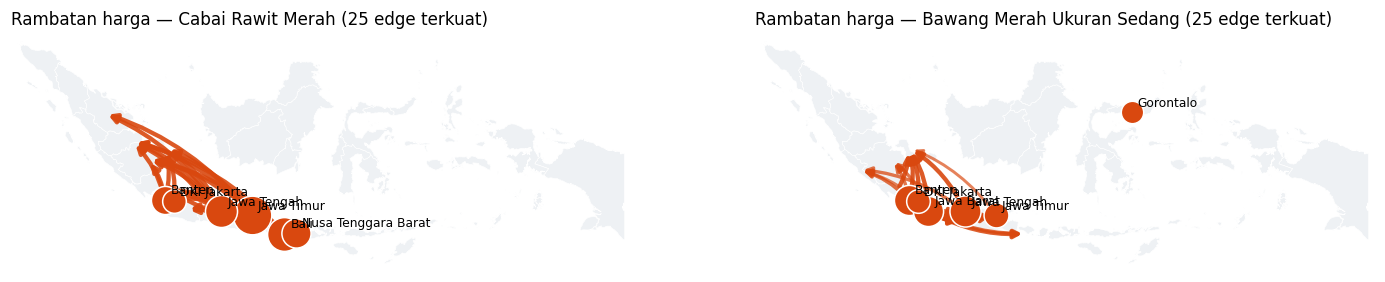

In [9]:
# Provinsi "pemimpin" per komoditas (data penuh): skor = edge keluar - edge masuk
pn = refs["prov_name"]
tops = []
for com_id in ["com_16", "com_14", "com_11", "com_7", "com_10", "com_3"]:
    t = ls_full[ls_full["commodity_id"] == com_id].head(3)
    tops.append({"komoditas": refs["com_name"][com_id],
                 "pemimpin #1": f"{pn[int(t.iloc[0].province_id)]} (+{t.iloc[0].leader_score})",
                 "pemimpin #2": f"{pn[int(t.iloc[1].province_id)]} (+{t.iloc[1].leader_score})",
                 "pemimpin #3": f"{pn[int(t.iloc[2].province_id)]} (+{t.iloc[2].leader_score})",
                 "edge signifikan": int(edges_full.query("commodity_id == @com_id")["significant"].sum())})
display(pd.DataFrame(tops))

fig, axes = plt.subplots(1, 2, figsize=(16, 4.6))
ref = province_reference()
for ax, com_id in zip(axes, ["com_16", "com_11"]):
    e = edges_full[(edges_full["commodity_id"] == com_id) & edges_full["significant"]]
    plot_network_map(ax, geo, ref, e, ls_full[ls_full["commodity_id"] == com_id], max_edges=25,
                     title=f"Rambatan harga — {refs['com_name'][com_id]} (25 edge terkuat)")
fig.savefig(P.figures / "fig_04_03_jaringan_rambatan.png", dpi=170, bbox_inches="tight"); plt.show()

## 4.5 Konstruksi & integrasi fitur
Integrasi 4 jenis pasar + jaringan + kalender + curah hujan menjadi satu tabel: **1 baris = (tanggal, varian, provinsi)**.

In [10]:
cal = calendar_features(Pc.index, holiday_table(Pc.index.min().year - 1, Pc.index.max().year + 2), cfg["features"]["calendar_cap_days"])
rain = rainfall_anomalies(rain_daily, cfg["weather"]["climatology_start"], cfg["weather"]["climatology_end"])
nbrs = nearest_neighbors(cfg["features"]["n_neighbors"])
print("Contoh tetangga:", {pn[p]: [pn[q] for q in nbrs[p]] for p in [13, 16, 26]})

t0 = time.time()
feats, groups = build_features(panels, labels, thr, cal, rain, nbrs, leaders_eval, refs["c2cat"], cfg,
                               province_names=pn, weekdays_only=cfg["validation"]["weekdays_only"])
print(f"Fitur (evaluasi) dibangun dalam {time.time() - t0:.0f} dtk: {feats.shape[0]:,} baris x {len(groups)} fitur")
feats.to_parquet(P.processed / "features.parquet", index=False)
(P.processed / "feature_groups.json").write_text(json.dumps(groups, indent=1))

t0 = time.time()
feats_final, _ = build_features(panels, labels, thr, cal, rain, nbrs, leaders_full, refs["c2cat"], cfg,
                                province_names=pn, weekdays_only=cfg["validation"]["weekdays_only"])
feats_final.to_parquet(P.processed / "features_final.parquet", index=False)
print(f"Fitur (final) dibangun dalam {time.time() - t0:.0f} dtk")
del feats_final

Contoh tetangga: {'DKI Jakarta': ['Banten', 'Jawa Barat', 'Lampung'], 'Jawa Timur': ['Jawa Tengah', 'DI Yogyakarta', 'Bali'], 'Sulawesi Selatan': ['Sulawesi Barat', 'Sulawesi Tenggara', 'Sulawesi Tengah']}


Fitur (evaluasi) dibangun dalam 6 dtk: 1,533,771 baris x 78 fitur


Fitur (final) dibangun dalam 9 dtk


In [11]:
dd = feature_dictionary(groups)
dd["persen_kosong"] = [feats[f].isna().mean() for f in dd["fitur"]]
dd.to_csv(P.tables / "04_data_dictionary.csv", index=False)
display(dd.groupby("kelompok").agg(jumlah_fitur=("fitur", "size"), rata2_kosong=("persen_kosong", "mean"))
          .sort_values("jumlah_fitur", ascending=False).style.format({"rata2_kosong": "{:.1%}"}))
display(dd.head(12))

,jumlah_fitur,rata2_kosong
kelompok,,
harga,20,1.6%
rantai_pasok,18,19.5%
kalender,13,0.0%
cuaca,10,0.0%
nasional,6,0.0%
tetangga,5,0.0%
identitas,3,0.0%
pemimpin,3,0.3%


,fitur,kelompok,deskripsi,persen_kosong
0,ret_1,harga,Perubahan log harga konsumen 1 hari,0.0000
1,ret_3,harga,Perubahan log harga konsumen 3 hari,0.0001
2,ret_7,harga,Perubahan log harga konsumen 7 hari,0.0002
3,ret_14,harga,Perubahan log harga konsumen 14 hari,0.0003
4,ret_28,harga,Perubahan log harga konsumen 28 hari,0.0004
5,ret_7_prev,harga,Perubahan log harga konsumen minggu sebelumnya...,0.0003
6,vol_7,harga,Volatilitas: simpangan baku perubahan log hari...,0.0001
7,vol_14,harga,Volatilitas: simpangan baku perubahan log hari...,0.0002
8,vol_30,harga,Volatilitas: simpangan baku perubahan log hari...,0.0003
9,z_30,harga,Z-score log harga terhadap 30 hari terakhir,0.0716


## 4.6 Uji kebocoran data (*leakage test*)
Jika fitur benar-benar hanya memakai masa lalu, maka membangun ulang fitur dengan **data yang dipotong di tanggal T** harus menghasilkan nilai **identik** untuk baris sebelum T.
(Toleransi 45 hari sebelum T karena deteksi salah input memakai beberapa observasi di sekitarnya — ini hanya memengaruhi *pembersihan data historis*, bukan fitur.)

In [12]:
T = pd.Timestamp("2024-06-28")
long_T = long[long["date"] <= T]
rain_T = rain_daily[rain_daily["date"] <= T]
panels_T, _ = build_price_panels(long_T, cfg)
Pc_T = panels_T[1]
labels_T = make_labels(Pc_T, threshold_per_column(Pc_T.columns, refs["c2cat"], cfg), cfg)
cal_T = calendar_features(Pc_T.index, holiday_table(2017, 2028), cfg["features"]["calendar_cap_days"])
rain_TT = rainfall_anomalies(rain_T, cfg["weather"]["climatology_start"], cfg["weather"]["climatology_end"])
f_T, _ = build_features(panels_T, labels_T, threshold_per_column(Pc_T.columns, refs["c2cat"], cfg), cal_T, rain_TT,
                        nbrs, leaders_eval, refs["c2cat"], cfg, province_names=pn)
cut = T - pd.Timedelta(days=45)
key = ["date", "commodity_id", "province_id"]
a_ = feats[feats["date"] <= cut].set_index(key).sort_index()
b_ = f_T[f_T["date"] <= cut].set_index(key).sort_index()
common = a_.index.intersection(b_.index)
fcols = [c for c in groups]
diff = (a_.loc[common, fcols] - b_.loc[common, fcols]).abs()
both_nan = a_.loc[common, fcols].isna() & b_.loc[common, fcols].isna()
mismatch = ((diff > 1e-4) | (a_.loc[common, fcols].isna() != b_.loc[common, fcols].isna())) & ~both_nan
res = mismatch.mean().sort_values(ascending=False)
print(f"Baris dibandingkan: {len(common):,} | fitur: {len(fcols)}")
print(f"Fitur dengan nilai berbeda: {(res > 0).sum()} -> {res[res > 0].round(6).to_dict()}")
assert (res <= 1e-4).all(), "Ada fitur yang memakai informasi masa depan!"
print("LULUS: fitur sebelum T identik walaupun data setelah T tidak ada -> tidak ada kebocoran masa depan.")
del f_T, a_, b_, diff, mismatch

Baris dibandingkan: 1,106,420 | fitur: 78
Fitur dengan nilai berbeda: 0 -> {}
LULUS: fitur sebelum T identik walaupun data setelah T tidak ada -> tidak ada kebocoran masa depan.


## 4.7 Ringkasan dataset siap model

In [13]:
mf = feats[(feats["eligible"] == 1) & feats["y"].notna()]
summary = pd.DataFrame({
    "baris total": [len(feats)], "baris eligible & berlabel": [len(mf)],
    "proporsi positif (y=1)": [mf["y"].mean()], "periode": [f"{feats['date'].min():%d %b %Y} – {feats['date'].max():%d %b %Y}"],
    "jumlah fitur": [len(groups)], "seri (varian x provinsi)": [feats.groupby(["commodity_id", "province_id"]).ngroups],
})
display(summary.T.rename(columns={0: "nilai"}))
pos = mf.groupby(mf["commodity_id"].map(refs["c2cat"]).map(refs["cat_name"]))["y"].agg(["mean", "size"])
pos.columns = ["proporsi positif", "baris"]
display(pos.sort_values("proporsi positif", ascending=False).style.format({"proporsi positif": "{:.2%}", "baris": "{:,}"}))

,nilai
baris total,1533771
baris eligible & berlabel,1451057
proporsi positif (y=1),0.0560
periode,02 Apr 2018 – 25 Sep 2026
jumlah fitur,78
seri (varian x provinsi),703


,proporsi positif,baris
commodity_id,,
Cabai Merah,25.46%,"109,920"
Cabai Rawit,21.09%,"113,284"
Bawang Merah,11.21%,"68,339"
Daging Ayam,5.43%,"72,774"
Bawang Putih,2.90%,"72,935"
Telur Ayam,1.98%,"74,189"
Minyak Goreng,1.78%,"216,490"
Daging Sapi,1.67%,"144,293"
Beras,1.44%,"432,749"


### Ringkasan fase 3
- Data bersih dari salah input; panel harian kalender untuk 4 jenis pasar.
- Target peringatan dini terdefinisi jelas (onset lonjakan dalam 14 hari) dengan ambang per kategori.
- Jaringan rambatan antarprovinsi dibangun dengan Granger bersyarat + FDR (implementasi diverifikasi terhadap statsmodels).
- **70+ fitur** dari 8 kelompok sinyal; **lulus uji leakage**.

➡️ Lanjut ke **`05_modeling.ipynb`**.